# Lab Assignment 4 - NLP
##### **Name:** Amit sharad pawar
##### **PRN:** 25070126501
##### **Title:** Implementation of Seq2Seq and LSTM for Text Classification

**Applications chosen (any three, as allowed):** 1) Sentiment Analysis, 2) Spam Detection, 3) Fake News Detection

For every application the same pipeline is used: load -> explore -> clean -> tokenize -> pad -> split -> build **LSTM** and **Seq2Seq (encoder-decoder LSTM)** -> train -> evaluate -> compare -> test on unseen text.

## Importing Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Hyper-parameters (kept small so everything trains quickly on a normal CPU / Colab)
MAX_WORDS = 5000     # vocabulary size
EMB_DIM   = 64       # embedding size
UNITS     = 64       # LSTM units
EPOCHS    = 10       # max epochs (early stopping may stop sooner)
BATCH     = 32

print("TensorFlow version:", tf.__version__)

I0000 00:00:1791027368.992936     720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791027369.042067     720 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791027370.420082     720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## Helper Functions
Everything that is common to the three applications is written once here and re-used.

* `clean_text` - lowercase + remove unnecessary characters
* `prepare_data` - clean, split, tokenize and pad
* `build_lstm` - plain LSTM classifier
* `build_seq2seq` - encoder-decoder (Seq2Seq) LSTM classifier
* `run_experiment` - trains both models, evaluates them and draws all the plots

In [2]:
def clean_text(text):
    text = text.lower()                      # lowercase conversion
    text = re.sub(r'[^a-z\s]', ' ', text)    # remove digits, punctuation, symbols
    text = re.sub(r'\s+', ' ', text).strip() # collapse extra spaces
    return text


def prepare_data(df, text_col, label_col, class_names, maxlen):
    """class_names[1] is treated as the POSITIVE class for Precision/Recall/F1."""
    df = df.copy()
    df['clean'] = df[text_col].apply(clean_text)
    y = df[label_col].map({c: i for i, c in enumerate(class_names)}).values

    # split first, then fit the tokenizer on the TRAIN part only (no test-data leakage)
    X_tr, X_te, y_tr, y_te = train_test_split(
        df['clean'], y, test_size=0.2, random_state=SEED, stratify=y)

    tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')   # tokenization
    tok.fit_on_texts(X_tr)

    def to_seq(texts):
        seq = tok.texts_to_sequences(texts)                    # words -> integers
        return pad_sequences(seq, maxlen=maxlen, padding='pre', truncating='post')  # padding

    X_tr_pad, X_te_pad = to_seq(X_tr), to_seq(X_te)

    print("Example cleaned text :", X_tr.iloc[0][:120], "...")
    print("Example token ids    :", tok.texts_to_sequences([X_tr.iloc[0]])[0][:15], "...")
    print("Example padded seq   :", X_tr_pad[0][-15:], "(last 15 of", maxlen, ")")
    print(f"Train: {X_tr_pad.shape} | Test: {X_te_pad.shape}")
    return X_tr_pad, X_te_pad, y_tr, y_te, tok


def build_lstm(maxlen, n_classes):
    # Many-to-one: the whole review is read, only the FINAL hidden state is used to classify.
    inp = Input(shape=(maxlen,))
    x = Embedding(MAX_WORDS, EMB_DIM)(inp)
    x = LSTM(UNITS)(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)
    model = Model(inp, out, name='LSTM_classifier')
    model.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_seq2seq(maxlen, n_classes):
    # ENCODER: reads the text and compresses it into the states (h, c)
    enc_in = Input(shape=(maxlen,), name='encoder_input')
    x = Embedding(MAX_WORDS, EMB_DIM)(enc_in)
    _, h, c = LSTM(UNITS, return_state=True, name='encoder_lstm')(x)

    # DECODER: starts from a <sos> token, is initialised with the encoder states (h, c)
    # and generates a 1-token output sequence = the class label.
    dec_in = Input(shape=(1,), name='decoder_input')            # <sos> token
    d = Embedding(n_classes + 1, 16)(dec_in)                    # ids 0..n-1 = labels, n = <sos>
    d = LSTM(UNITS, return_sequences=True, name='decoder_lstm')(d, initial_state=[h, c])
    out = Dense(n_classes, activation='softmax')(d)             # shape (batch, 1, n_classes)

    model = Model([enc_in, dec_in], out, name='Seq2Seq_classifier')
    model.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def metrics_of(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall":    recall_score(y_true, y_pred),
            "F1-Score":  f1_score(y_true, y_pred)}

In [3]:
def run_experiment(app_name, df, text_col, label_col, class_names, maxlen, unseen_texts):
    n_classes = len(class_names)
    SOS = n_classes                                   # id of the <sos> start token for the decoder

    print("=" * 70, f"\n{app_name}\n", "=" * 70, sep="")
    X_tr, X_te, y_tr, y_te, tok = prepare_data(df, text_col, label_col, class_names, maxlen)

    # decoder inputs / targets for Seq2Seq (the target "sequence" is just the label)
    dec_tr, dec_te = np.full((len(y_tr), 1), SOS), np.full((len(y_te), 1), SOS)
    es = lambda: EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # ---- train LSTM ----
    lstm = build_lstm(maxlen, n_classes)
    h_lstm = lstm.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS,
                      batch_size=BATCH, callbacks=[es()], verbose=2)

    # ---- train Seq2Seq ----
    s2s = build_seq2seq(maxlen, n_classes)
    h_s2s = s2s.fit([X_tr, dec_tr], y_tr.reshape(-1, 1), validation_split=0.1,
                    epochs=EPOCHS, batch_size=BATCH, callbacks=[es()], verbose=2)

    # ---- evaluate on the test set ----
    p_lstm = lstm.predict(X_te, verbose=0).argmax(axis=1)
    p_s2s  = s2s.predict([X_te, dec_te], verbose=0).argmax(axis=-1).ravel()
    res = {"LSTM": metrics_of(y_te, p_lstm), "Seq2Seq": metrics_of(y_te, p_s2s)}
    res_df = pd.DataFrame(res).T.round(4)
    print(f"\nTest results - {app_name} (positive class = '{class_names[1]}')")
    display(res_df)

    # ---- confusion matrices ----
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (name, pred) in zip(axes, [("LSTM", p_lstm), ("Seq2Seq", p_s2s)]):
        sns.heatmap(confusion_matrix(y_te, pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names)
        ax.set_title(f"{name} - Confusion Matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

    # ---- training / validation accuracy and loss ----
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for row, (name, h) in enumerate([("LSTM", h_lstm), ("Seq2Seq", h_s2s)]):
        for col, m in enumerate(["accuracy", "loss"]):
            axes[row, col].plot(h.history[m], marker='o', label='Train')
            axes[row, col].plot(h.history['val_' + m], marker='o', label='Validation')
            axes[row, col].set_title(f"{name} - {m.capitalize()}")
            axes[row, col].set_xlabel("Epoch"); axes[row, col].legend()
    plt.tight_layout(); plt.show()

    # ---- unseen samples ----
    seqs = pad_sequences(tok.texts_to_sequences([clean_text(t) for t in unseen_texts]),
                         maxlen=maxlen, padding='pre', truncating='post')
    u_lstm = lstm.predict(seqs, verbose=0).argmax(axis=1)
    u_s2s  = s2s.predict([seqs, np.full((len(seqs), 1), SOS)], verbose=0).argmax(axis=-1).ravel()
    unseen = pd.DataFrame({"Text": [t[:70] + ("..." if len(t) > 70 else "") for t in unseen_texts],
                           "LSTM prediction": [class_names[i] for i in u_lstm],
                           "Seq2Seq prediction": [class_names[i] for i in u_s2s]})
    print("\nPredictions on new / unseen samples:")
    display(unseen)

    return res_df

---
# Application 1: Sentiment Analysis (Positive / Negative)
**Dataset:** SST-2 (Stanford Sentiment Treebank, binary version) - 9,613 movie-review sentences from Rotten Tomatoes labelled positive / negative (train + dev + test files merged).

*Why not the NLTK `movie_reviews` corpus from Assignments 1-3?* It has only 2000 documents, which is far too little to train an LSTM from scratch (in a first trial both models stayed near 50% accuracy and simply memorised the training set), so a larger dataset of the same domain was used.

In [4]:
base = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/"
parts = [pd.read_csv(base + f, sep='\t', header=None, names=['text', 'label']) for f in ['train.tsv', 'dev.tsv', 'test.tsv']]
df_sent = pd.concat(parts, ignore_index=True)
df_sent['label'] = df_sent['label'].map({0: 'neg', 1: 'pos'})

print("Shape:", df_sent.shape)
print("Text column  : 'text'")
print("Target column: 'label'")
print(df_sent['label'].value_counts())
print("Average sentence length (words):", int(df_sent['text'].str.split().str.len().mean()))
df_sent.head()

Shape: (9613, 2)
Text column  : 'text'
Target column: 'label'
label
pos    4963
neg    4650
Name: count, dtype: int64


Average sentence length (words): 18


,text,label
0,"a stirring , funny and finally transporting re...",pos
1,apparently reassembled from the cutting room f...,neg
2,they presume their audience wo n't sit still f...,neg
3,this is a visually stunning rumination on love...,pos
4,jonathan parker 's bartleby should have been t...,pos


Sentiment Analysis


Example cleaned text : there s an underlying old world sexism to monday morning that undercuts its charm ...
Example token ids    : [51, 7, 18, 3256, 128, 138, 1, 6, 1, 2679, 11, 4001, 20, 265] ...
Example padded seq   : [   0   51    7   18 3256  128  138    1    6    1 2679   11 4001   20
  265] (last 15 of 50 )
Train: (7690, 50) | Test: (1923, 50)
Epoch 1/10


217/217 - 5s - 23ms/step - accuracy: 0.6579 - loss: 0.6067 - val_accuracy: 0.7724 - val_loss: 0.4635


Epoch 2/10


217/217 - 5s - 23ms/step - accuracy: 0.8457 - loss: 0.3538 - val_accuracy: 0.8036 - val_loss: 0.5221


...

217/217 - 5s - 24ms/step - accuracy: 0.9408 - loss: 0.1532 - val_accuracy: 0.8114 - val_loss: 0.8076


Epoch 5/10


217/217 - 5s - 24ms/step - accuracy: 0.9587 - loss: 0.1091 - val_accuracy: 0.7841 - val_loss: 0.9154



Test results - Sentiment Analysis (positive class = 'pos')


,Accuracy,Precision,Recall,F1-Score
LSTM,0.7748,0.7414,0.8661,0.7989
Seq2Seq,0.7894,0.7888,0.8087,0.7986


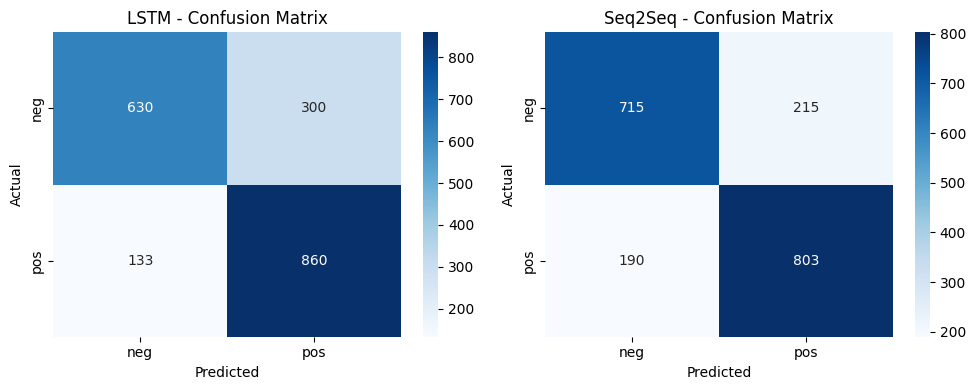

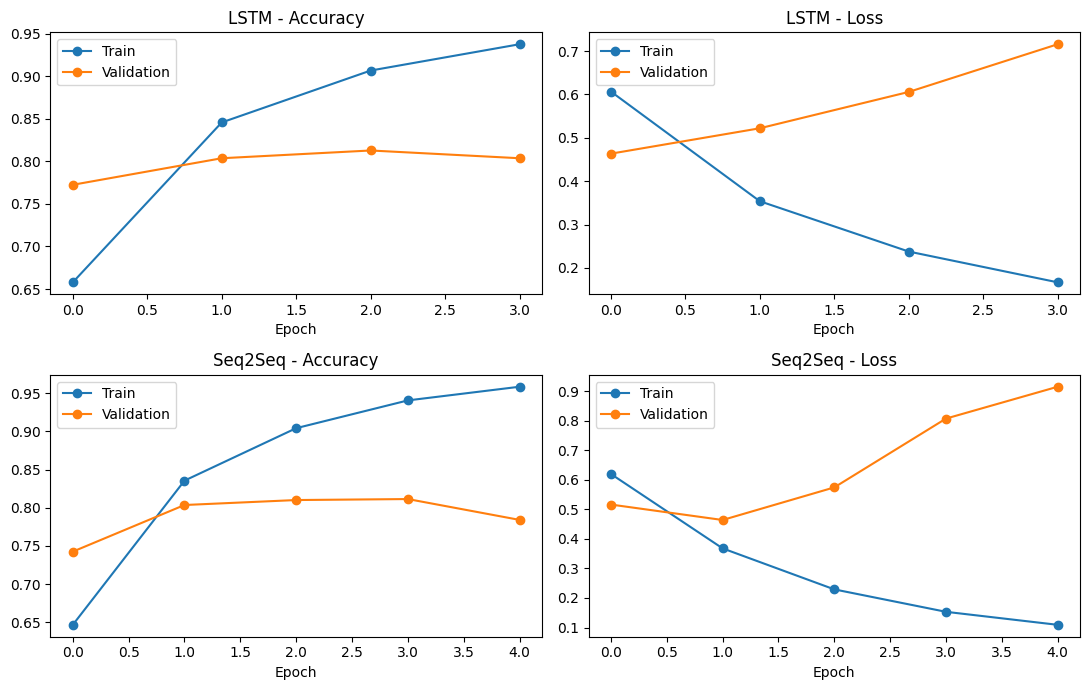


Predictions on new / unseen samples:


,Text,LSTM prediction,Seq2Seq prediction
0,An absolutely brilliant film with superb actin...,pos,pos
1,A boring and predictable plot with terrible ac...,neg,neg
2,The movie had some funny moments and great mus...,pos,pos


In [5]:
sent_unseen = [
    "An absolutely brilliant film with superb acting and a gripping story that kept me hooked till the end",
    "A boring and predictable plot with terrible acting. A complete waste of time and money",
    "The movie had some funny moments and great music but the ending was disappointing",
]
res_sent = run_experiment("Sentiment Analysis", df_sent, 'text', 'label',
                          class_names=['neg', 'pos'], maxlen=50, unseen_texts=sent_unseen)

---
# Application 2: Spam Detection (Spam / Not Spam)
**Dataset:** SMS Spam Collection (UCI), 5572 SMS messages labelled `ham` (not spam) or `spam`.

In [6]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df_spam = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

print("Shape:", df_spam.shape)
print("Text column  : 'text'")
print("Target column: 'label'")
print(df_spam['label'].value_counts())
print("Average message length (words):", int(df_spam['text'].str.split().str.len().mean()))
df_spam.head()

Shape: (5572, 2)
Text column  : 'text'
Target column: 'label'
label
ham     4825
spam     747
Name: count, dtype: int64
Average message length (words): 15


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Spam Detection


Example cleaned text : he will you guys close ...
Example token ids    : [66, 36, 4, 335, 645] ...
Example padded seq   : [  0   0   0   0   0   0   0   0   0   0  66  36   4 335 645] (last 15 of 50 )
Train: (4457, 50) | Test: (1115, 50)


Epoch 1/10


126/126 - 4s - 29ms/step - accuracy: 0.9399 - loss: 0.1786 - val_accuracy: 0.9888 - val_loss: 0.0626


Epoch 2/10


...

126/126 - 3s - 21ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 0.9910 - val_loss: 0.0481


Epoch 5/10


126/126 - 3s - 21ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.9910 - val_loss: 0.0533



Test results - Spam Detection (positive class = 'spam')


,Accuracy,Precision,Recall,F1-Score
LSTM,0.9857,0.9524,0.9396,0.9459
Seq2Seq,0.9874,0.9655,0.9396,0.9524


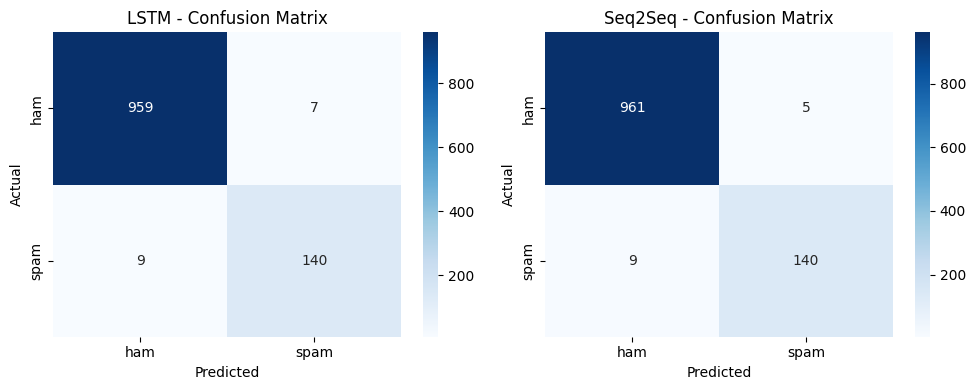

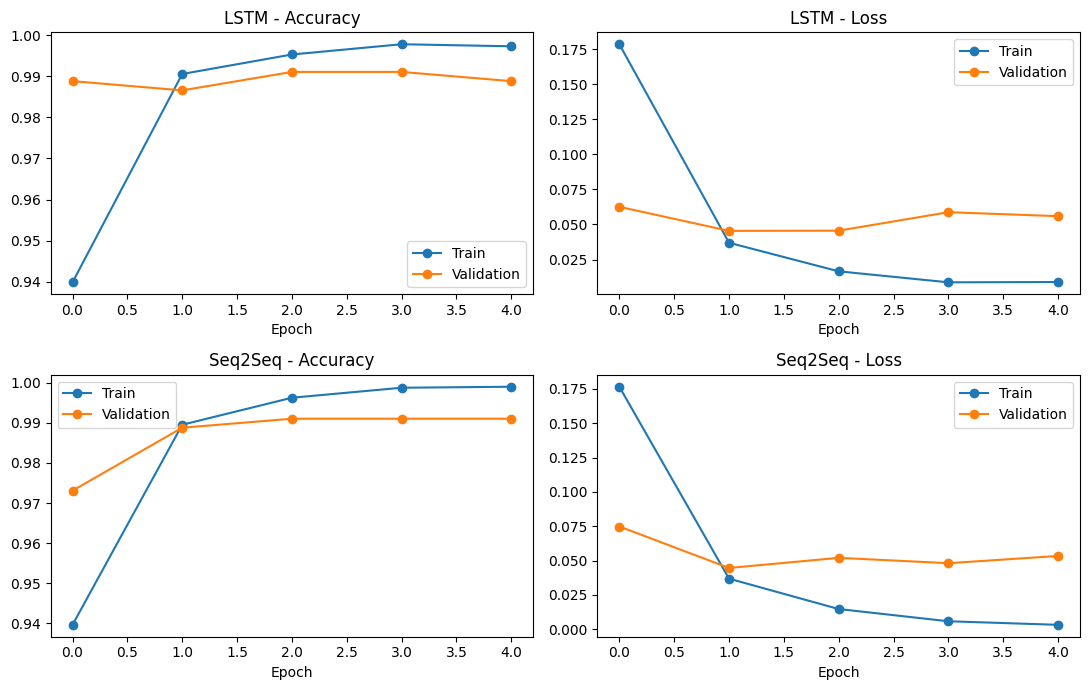


Predictions on new / unseen samples:


,Text,LSTM prediction,Seq2Seq prediction
0,Congratulations! You have won a free holiday t...,spam,spam
1,"Hey, are we still meeting for lunch tomorrow a...",ham,ham
2,URGENT! Your bank account has been suspended. ...,spam,spam


In [7]:
spam_unseen = [
    "Congratulations! You have won a free holiday ticket. Call now to claim your prize",
    "Hey, are we still meeting for lunch tomorrow at 1?",
    "URGENT! Your bank account has been suspended. Click the link to verify and win 500 cash",
]
res_spam = run_experiment("Spam Detection", df_spam, 'text', 'label',
                          class_names=['ham', 'spam'], maxlen=50, unseen_texts=spam_unseen)

---
# Application 3: Fake News Detection (Fake / Real)
**Dataset:** `fake_or_real_news` - 6335 news articles (title + text) labelled `FAKE` or `REAL`.

In [8]:
url = "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv"
df_fake = pd.read_csv(url)
df_fake['content'] = df_fake['title'] + ' ' + df_fake['text']     # use headline + body together

print("Shape:", df_fake.shape)
print("Text column  : 'content' (title + text)")
print("Target column: 'label'")
print(df_fake['label'].value_counts())
print("Average article length (words):", int(df_fake['content'].str.split().str.len().mean()))
df_fake[['title', 'label']].head()

Shape: (6335, 5)
Text column  : 'content' (title + text)
Target column: 'label'
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


Average article length (words): 786


,title,label
0,You Can Smell Hillary’s Fear,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matters,REAL


Fake News Detection


Example cleaned text : like a good little sharia compliant female prince charles wife camilla removes her shoes to enter a mosque in abu dhabi  ...
Example token ids    : [79, 6, 205, 336, 1, 1, 1382, 4768, 2012, 863, 1, 1, 51, 1, 3] ...
Example padded seq   : [   5  630    1    5 1797 1764  449    2  152 1182    1    5  398    2
  109] (last 15 of 300 )
Train: (5068, 300) | Test: (1267, 300)
Epoch 1/10


143/143 - 13s - 90ms/step - accuracy: 0.6759 - loss: 0.6144 - val_accuracy: 0.7199 - val_loss: 0.5536


Epoch 2/10


143/143 - 20s - 139ms/step - accuracy: 0.8360 - loss: 0.3980 - val_accuracy: 0.7929 - val_loss: 0.5343


...

143/143 - 21s - 147ms/step - accuracy: 0.8945 - loss: 0.2780 - val_accuracy: 0.8028 - val_loss: 0.5171


Epoch 5/10


143/143 - 21s - 144ms/step - accuracy: 0.9191 - loss: 0.2241 - val_accuracy: 0.7160 - val_loss: 0.6547



Test results - Fake News Detection (positive class = 'FAKE')


,Accuracy,Precision,Recall,F1-Score
LSTM,0.8627,0.8768,0.8436,0.8599
Seq2Seq,0.8327,0.8233,0.8468,0.8349


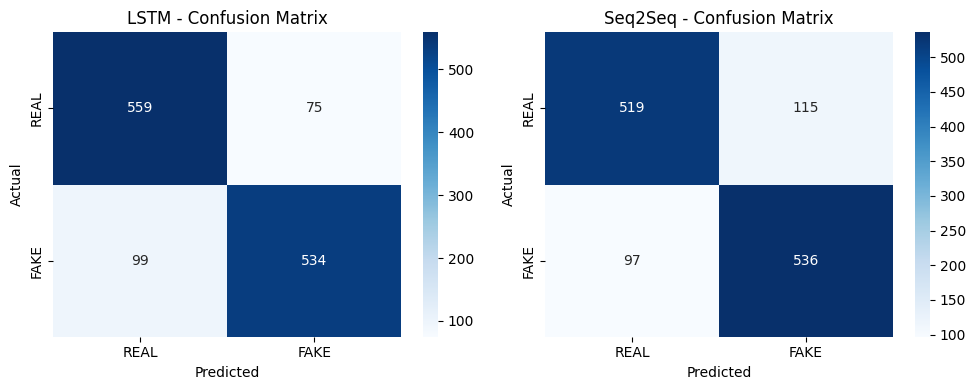

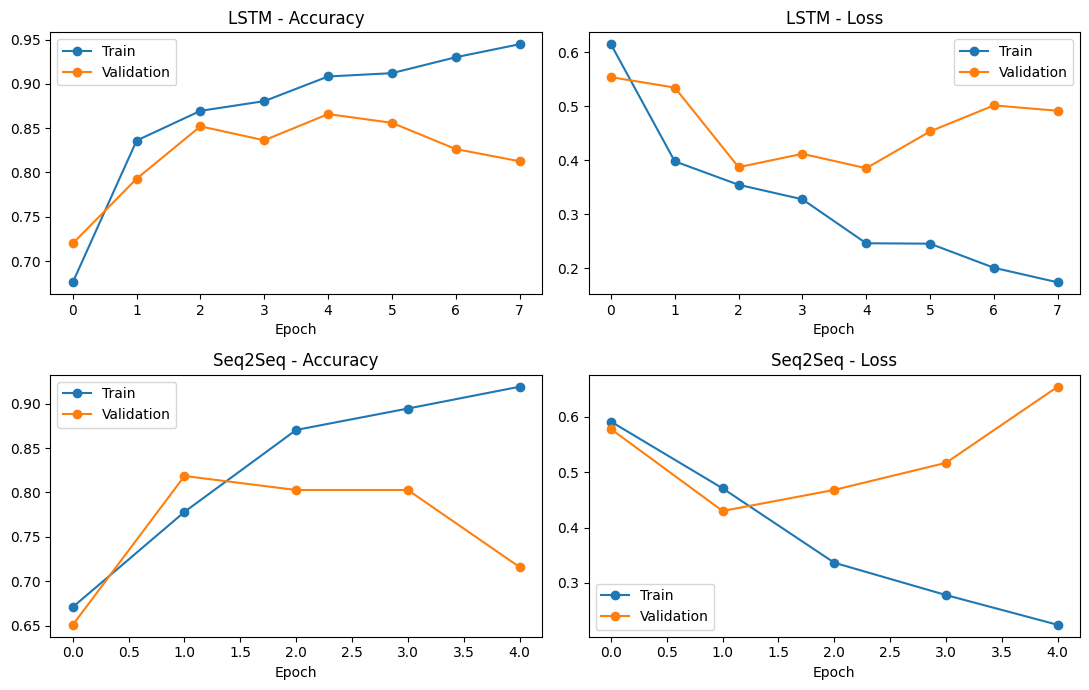


Predictions on new / unseen samples:


,Text,LSTM prediction,Seq2Seq prediction
0,BREAKING: Shocking secret documents reveal the...,FAKE,FAKE
1,The Senate passed a bipartisan spending bill o...,REAL,REAL
2,Anonymous sources claim the election was rigge...,FAKE,FAKE


In [9]:
fake_unseen = [
    "BREAKING: Shocking secret documents reveal the truth they do not want you to know. Share before it gets deleted!",
    "The Senate passed a bipartisan spending bill on Tuesday after weeks of negotiations, officials said",
    "Anonymous sources claim the election was rigged by a secret group and the media is hiding everything",
]
res_fake = run_experiment("Fake News Detection", df_fake, 'content', 'label',
                          class_names=['REAL', 'FAKE'], maxlen=300, unseen_texts=fake_unseen)

---
# Final Comparison: LSTM vs Seq2Seq (all three applications)

Accuracy  Precision  Recall  F1-Score
Application         Model                                         
Sentiment Analysis  LSTM       0.7748     0.7414  0.8661    0.7989
                    Seq2Seq    0.7894     0.7888  0.8087    0.7986
Spam Detection      LSTM       0.9857     0.9524  0.9396    0.9459
                    Seq2Seq    0.9874     0.9655  0.9396    0.9524
Fake News Detection LSTM       0.8627     0.8768  0.8436    0.8599
                    Seq2Seq    0.8327     0.8233  0.8468    0.8349

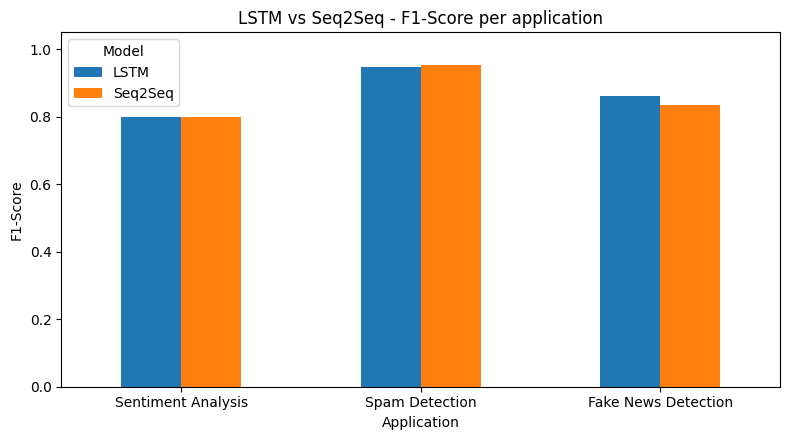

In [10]:
summary = pd.concat({"Sentiment Analysis": res_sent,
                     "Spam Detection": res_spam,
                     "Fake News Detection": res_fake}, names=["Application", "Model"])
display(summary)

f1 = summary['F1-Score'].unstack()
f1.plot(kind='bar', figsize=(8, 4.5), rot=0)
plt.ylabel("F1-Score"); plt.ylim(0, 1.05); plt.title("LSTM vs Seq2Seq - F1-Score per application")
plt.legend(title="Model"); plt.tight_layout(); plt.show()

## Observations from the results
* **Sentiment Analysis:** both models reach an F1 of about 0.80 (LSTM 0.7989, Seq2Seq 0.7986). Seq2Seq has the higher accuracy and precision, the LSTM the higher recall.
* **Spam Detection:** both are excellent (accuracy about 98.6-98.7%). Seq2Seq is ahead by only about 2 messages out of 1115 (F1 0.9524 vs 0.9459). Because only ~13% of the messages are spam, F1 / precision / recall are more meaningful than accuracy here.
* **Fake News Detection:** the LSTM is clearly better (F1 0.8599 vs 0.8349, accuracy 0.8627 vs 0.8327). The articles are long (300 tokens kept), so the simpler model generalised better.
* In every training plot the validation loss starts rising after the first few epochs while training accuracy keeps climbing - the models overfit quickly, which is why early stopping (restoring the best weights) was used.
* All numbers come from a single run with a fixed seed and a small test set, so differences of 1-2 points should not be over-interpreted.

## Major Difference: LSTM-based vs Seq2Seq-based Classification

| Aspect | LSTM classifier | Seq2Seq (Encoder-Decoder) classifier |
|---|---|---|
| Architecture | Embedding -> LSTM -> Dense (softmax) | Encoder LSTM -> context states (h, c) -> Decoder LSTM -> Dense (softmax) |
| How the label is produced | The final hidden state of the LSTM is fed directly to the output layer | The decoder is started with a `<sos>` token, initialised with the encoder states, and *generates* the label as an output sequence of length 1 |
| Inputs | One input (the text) | Two inputs (the text for the encoder + the `<sos>` token for the decoder) |
| Designed for | Many-to-one problems (text -> one class) | Many-to-many problems (text -> sequence), e.g. translation, summarisation |

**In short:** the LSTM classifier *reads and classifies*, whereas the Seq2Seq model *reads (encoder) and then writes the answer (decoder)*. For plain classification the output sequence has only one token, so the decoder adds no new information - the encoder state is still the only bottleneck.

### Advantages and Limitations
| Approach | Advantage | Limitation |
|---|---|---|
| **LSTM** | Simple, fewer parameters, faster to train and less prone to overfitting; best choice for single-label classification | The whole text must be squeezed into one fixed-size final state, so information from long texts can be lost; reads words strictly one after another (no parallelism) |
| **Seq2Seq** | Flexible - the same architecture can output longer sequences (multi-label outputs, label + explanation, tagging) and the decoder can model dependencies between output tokens | More parameters and more complex; for a single class label the decoder is redundant and it overfits more easily; still limited by the fixed-size context vector (no attention) |

## Conclusion
LSTM and Seq2Seq (encoder-decoder LSTM) models were built for three applications - Sentiment Analysis, Spam Detection and Fake News Detection - and evaluated with Accuracy, Precision, Recall, F1-Score and confusion matrices.

Both architectures gave very similar results: Seq2Seq was marginally better on Spam Detection (F1 0.9524 vs 0.9459) and had slightly higher accuracy on Sentiment Analysis (0.7894 vs 0.7748, F1 tied at about 0.80), while the plain LSTM was clearly better on Fake News Detection (F1 0.8599 vs 0.8349), where the input texts are long. Since the Seq2Seq decoder only has to emit one label, it brings little extra benefit for classification and costs more parameters; the simpler LSTM is therefore the more practical choice here, and Seq2Seq becomes worthwhile when the output itself is a sequence. Both models overfit quickly, so early stopping, dropout, pre-trained embeddings or more data would be natural next steps.